### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [29]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import dlib

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, utils, Model, optimizers, callbacks
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.data import Dataset

### Step 2: Load Data

In [5]:
path_with_mask = './data/face_mask_dataset/data/with_mask/'
path_without_mask = './data/face_mask_dataset/data/without_mask/'

In [6]:
df_mask = pd.DataFrame(
    {
        'image': os.listdir(path_with_mask),
        'target': 1
    }
)

In [7]:
df_without_mask = pd.DataFrame(
    {
        'image': os.listdir(path_without_mask),
        'target': 0
    }
)

In [8]:
df = pd.concat([df_mask, df_without_mask], ignore_index=True)

In [9]:
df.sample(5)

,image,target
1144,with_mask_2028.jpg,1
5379,without_mask_2488.jpg,0
1683,with_mask_2513.jpg,1
5347,without_mask_2459.jpg,0
3038,with_mask_380.jpg,1


### Step 3: Exploaring Data

#### Basic Info

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
target,7553.0,0.493182,0.499987,0.0,0.0,0.0,1.0,1.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7553 entries, 0 to 7552
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   7553 non-null   object
 1   target  7553 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.1+ KB


#### Target Distribution

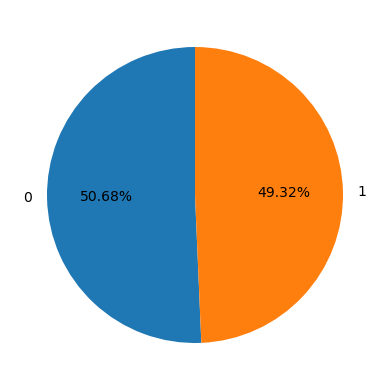

In [12]:
plt.figure(figsize=(4, 4))
plt.pie(
    df['target'].value_counts(),
    autopct='%.2f%%',
    labels=df['target'].value_counts().index,
    startangle=90
)
plt.tight_layout()

### Step 4: Split Data

In [13]:
train, test = train_test_split(
    df,
    test_size=0.4,
    random_state=42
)

In [14]:
test, value = train_test_split(
    test,
    test_size=0.5,
    random_state=42
)

### Stept5: Constant

In [15]:
IMG_HEIGHT = 150
IMG_WIDTH = 150
IMG_CHANNEL = 3
BATCH_SIZE = 25

### Step 6: Building Dataset

In [16]:
def generator(df, image_shape):
    def gen():
        for _, row in df.iterrows():
            label = row['target']
            image_fold = path_with_mask if label else path_without_mask
            image = load_img(os.path.join(image_fold, row['image']), target_size=image_shape)
            image = img_to_array(image)
            image = image / 255.0
            yield image, label

    return Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=image_shape, dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )
    )

In [17]:
def get_generator(df, image_shape, batch_size):
    gen = generator(df, image_shape)
    gen = gen.shuffle(buffer_size=len(df))
    gen = gen.batch(batch_size)
    gen = gen.prefetch(tf.data.AUTOTUNE)
    return gen

In [18]:
train_generator = get_generator(train, (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE)
value_generator = get_generator(value, (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE)
test_generator = get_generator(test, (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNEL), 1)

### Step 7: Building Model

In [19]:
inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNEL))
x = layers.Conv2D(100, (3, 3), activation='relu')(inputs)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Conv2D(100, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(50, activation='relu')(x)
outputs = layers.Dense(2, activation='softmax')(x)

In [20]:
model = Model(inputs, outputs)

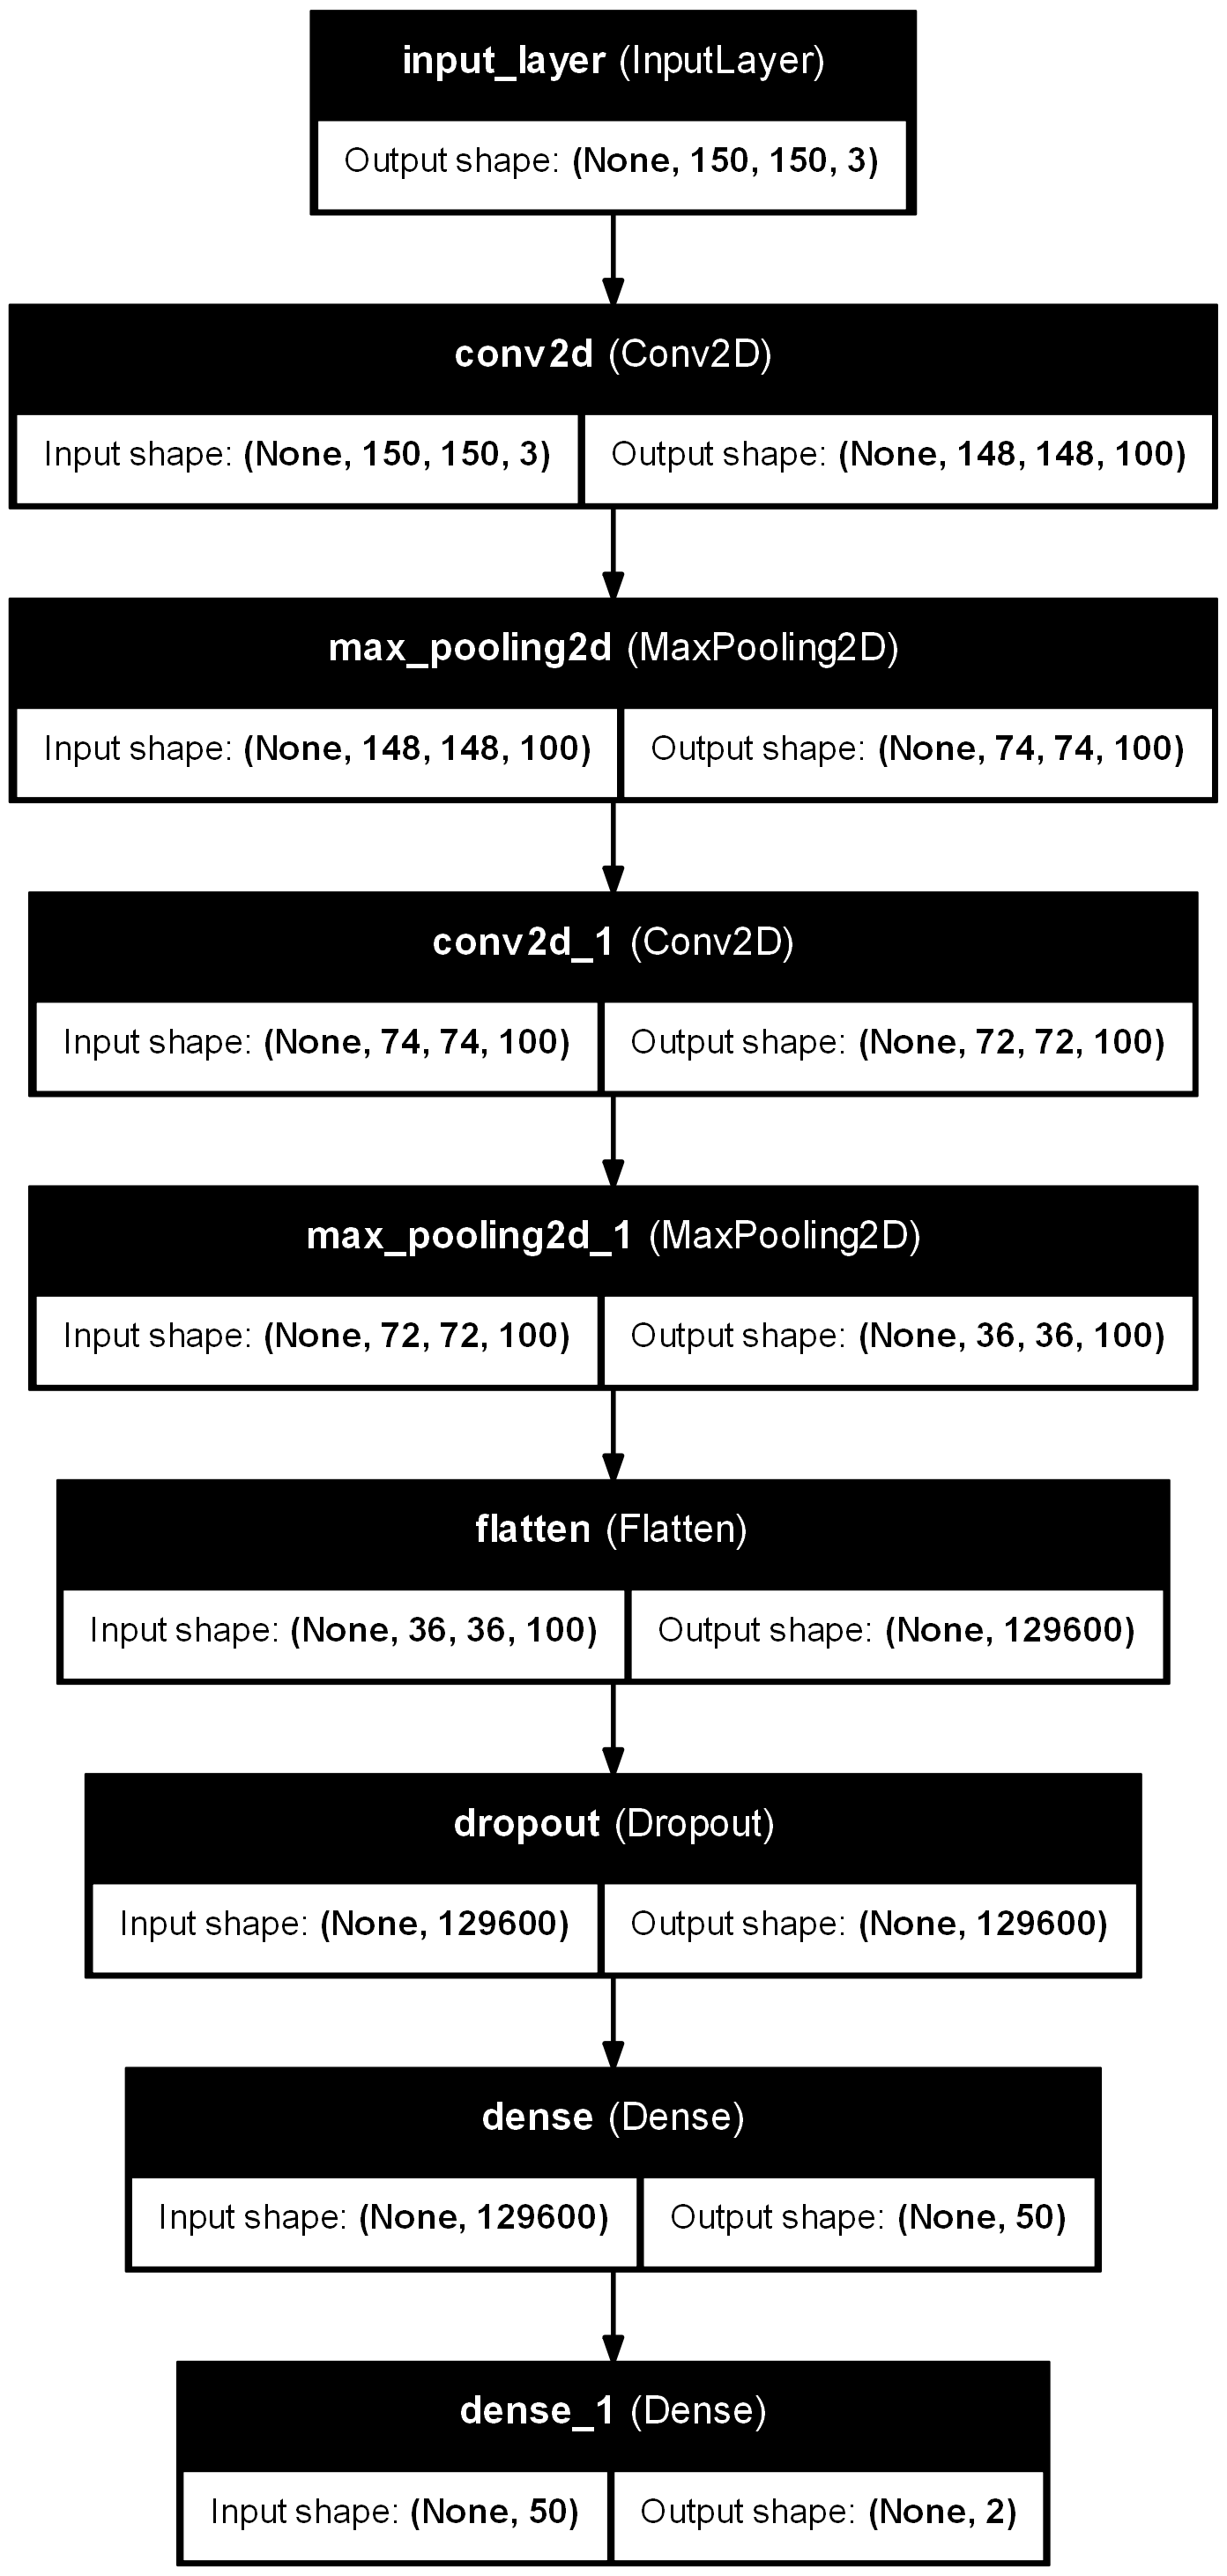

In [21]:
utils.plot_model(model, show_layer_names=True, show_shapes=True)

In [22]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 148, 148, 100)       │           2,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 100)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 100)         │          90,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 100)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 129600)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 129600)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 50)                  │       6,480,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             102 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,573,052 (25.07 MB)

 Trainable params: 6,573,052 (25.07 MB)

 Non-trainable params: 0 (0.00 B)

### Step 8: Compile and Training Model

In [23]:
optimizer = optimizers.Adam(learning_rate=0.001, clipnorm=1.0)

In [24]:
model.compile(
    optimizer=optimizer,
    # loss='binary_crossentropy',
    loss='sparse_categorical_crossentropy',
    metrics=['acc']
)

In [25]:
def lr_scheduler(epoch):
    if epoch < 5:
        return 0.001
    else:
        return 0.001 * math.exp(-0.1*(epoch-2))
lr_schedule = callbacks.LearningRateScheduler(lr_scheduler)

In [26]:
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [27]:
history = model.fit(
    train_generator,
    validation_data=value_generator,
    epochs=10,
    callbacks=[early_stopping, lr_schedule]
)

Epoch 1/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 154s 573ms/step - acc: 0.8285 - loss: 0.4010 - val_acc: 0.8961 - val_loss: 0.2635 - learning_rate: 0.0010
Epoch 2/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 109s 508ms/step - acc: 0.8828 - loss: 0.2824 - val_acc: 0.8815 - val_loss: 0.2847 - learning_rate: 0.0010
Epoch 3/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 112s 516ms/step - acc: 0.9119 - loss: 0.2182 - val_acc: 0.9146 - val_loss: 0.2371 - learning_rate: 0.0010
Epoch 4/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 113s 524ms/step - acc: 0.9289 - loss: 0.1770 - val_acc: 0.9186 - val_loss: 0.2187 - learning_rate: 0.0010
Epoch 5/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 113s 530ms/step - acc: 0.9473 - loss: 0.1361 - val_acc: 0.8908 - val_loss: 0.2844 - learning_rate: 0.0010
Epoch 6/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 113s 535ms/step - acc: 0.9625 - loss: 0.0978 - val_acc: 0.9252 - val_loss: 0.2561 - learning_rate: 7.4082e-04
Epoch 7/10
182/182 ━━━━━━━━━━━━━━━━━━━━ 114s 536ms/step - acc: 0.9764 - loss: 0.0650 - val_acc: 0.9305 - val_loss: 0.286

### Step 9: Predict Model

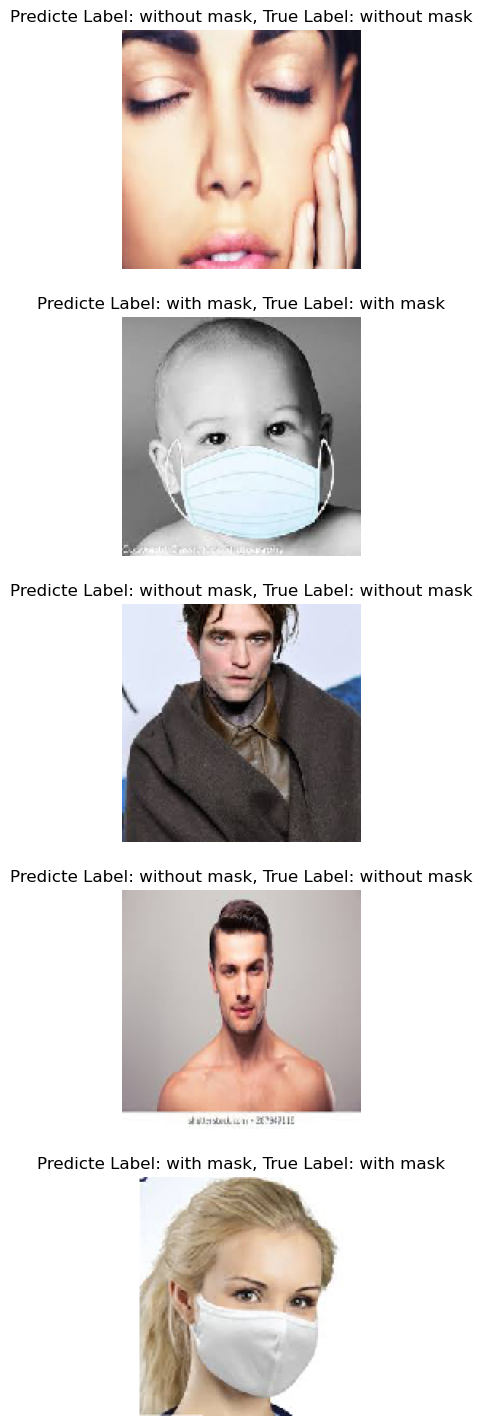

In [28]:
plt.figure(figsize=(10, 18))
i = 1
for image, label in test_generator.take(5):
    plt.subplot(5, 1, i)
    y_pred = model.predict(image, verbose=0)
    target_pred = 'with mask' if np.argmax(y_pred) else 'without mask'
    true_pred = 'with mask' if label else 'without mask'
    plt.title(f'Predicte Label: {target_pred}, True Label: {true_pred}')
    plt.imshow(image[0])
    plt.axis('off')
    i+=1

### Step 10: Detecting the Faces with and without Masks

In [116]:
cap = cv2.VideoCapture(0)
detector = dlib.get_frontal_face_detector()

In [117]:
frame_list = list()

In [118]:
while True:
    ret, frame = cap.read()
    frame = cv2.flip(frame, 1)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)

    i = 0
    for face in faces:
        x, y = face.left(), face.top()
        x1, y1 = face.right(), face.bottom()
        cv2.rectangle(frame, (x, y), (x1, y1), (0, 255, 0), 2)
        
        target_image = frame[y+2:y1-2, x+2:x1-2, :]
        target_image = cv2.cvtColor(target_image, cv2.COLOR_BGR2RGB)
        target_image = tf.image.resize(target_image, [IMG_HEIGHT, IMG_WIDTH])
        target_image = np.expand_dims(target_image, 0) / 255.0
        target_pred = model.predict(target_image, verbose=0)
        target_label = 'with mask' if np.argmax(target_pred) else 'without mask'
        if target_label == 'with mask':
            frame_list.append(frame)
        
        i += 1

        cv2.putText(frame, f'face num{i}: {target_label}', (x-10, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    cv2.imshow('frame', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

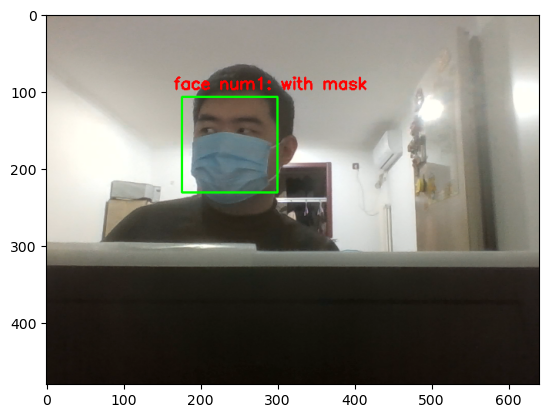

In [128]:
plt.imshow(cv2.cvtColor(frame_list[44], cv2.COLOR_BGR2RGB))